<a href="https://colab.research.google.com/github/josevalladares99/Proyecto_Electiva2/blob/main/Notebook/Proyecto_Electiva2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Carga del dataset**

In [1]:
import pandas as pd

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
filename='/content/drive/MyDrive/Proyecto_Electiva2/CSV/risk-prediction.csv'

In [5]:
df = pd.read_csv(filename)
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


## **Observaciones del dataset**


In [6]:
df.shape

(308854, 19)

In [7]:
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

In [9]:
df.isnull().sum()

,0
General_Health,0
Checkup,0
Exercise,0
Heart_Disease,0
Skin_Cancer,0
Other_Cancer,0
Depression,0
Diabetes,0
Arthritis,0
Sex,0


In [10]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


## **Preparación de datos**

In [11]:
# Crear la nueva columna 'Total_Diseases' (Total de enfermedades)
disease_columns = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis']
df['Total_Diseases'] = df[disease_columns].eq('Yes').sum(axis=1)

# Mostrar parte del DataFrame resultante
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Total_Diseases
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0,1
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0,2
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0,1
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0,2
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0,0


In [12]:
# Definir una función para asignar el estado de peso basado en el valor de BMI
def assign_weight_status(bmi):
    if bmi < 18.5:
        return 'Bajo peso'
    elif 18.5 <= bmi <= 24.9:
        return 'Saludable'
    elif 25 <= bmi <= 29.9:
        return 'Sobrepeso'
    elif 30 <= bmi:
        return 'Obesidad'

# Aplicar la función a la columna 'BMI' y crear la nueva columna 'estado de peso'
df['Weight_Status'] = df['BMI'].apply(assign_weight_status)

# Mostrar parte del DataFrame resultante
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Total_Diseases,Weight_Status
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0,1,Bajo peso
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0,2,Sobrepeso
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0,1,Obesidad
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0,2,Sobrepeso
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0,0,Saludable


In [13]:
# Definir el nuevo orden de las columnas
new_column_order = [
    'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Weight_Status', 'General_Health', 'Checkup',
    'Exercise', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'Smoking_History', 'Alcohol_Consumption',
    'FriedPotato_Consumption', 'Heart_Disease', 'Diabetes', 'Skin_Cancer', 'Other_Cancer', 'Depression',
    'Arthritis', 'Total_Diseases'
]

# Reordenar las columnas del DataFrame según el nuevo orden
health_data = df[new_column_order]

# Ajustar la configuración de visualización para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar parte del DataFrame resultante
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Total_Diseases,Weight_Status
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0,1,Bajo peso
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0,2,Sobrepeso
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0,1,Obesidad
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0,2,Sobrepeso
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0,0,Saludable


In [14]:
# Verificar el tipo de dato actual de las variables
print(df.dtypes)

General_Health                   object
Checkup                          object
Exercise                         object
Heart_Disease                    object
Skin_Cancer                      object
Other_Cancer                     object
Depression                       object
Diabetes                         object
Arthritis                        object
Sex                              object
Age_Category                     object
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                  object
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
Total_Diseases                    int64
Weight_Status                    object
dtype: object


In [15]:
# Cambio del tipo de dato de cada variable para optimizar el dataset
df["Sex"] = df["Sex"].astype("category")
df["Age_Category"] = df["Age_Category"].astype("category")
df["Weight_Status"] = df["Weight_Status"].astype("category")
df["General_Health"] = df["General_Health"].astype("category")

# Verificar el tipo de dato después del cambio
print(df.dtypes)

General_Health                  category
Checkup                           object
Exercise                          object
Heart_Disease                     object
Skin_Cancer                       object
Other_Cancer                      object
Depression                        object
Diabetes                          object
Arthritis                         object
Sex                             category
Age_Category                    category
Height_(cm)                      float64
Weight_(kg)                      float64
BMI                              float64
Smoking_History                   object
Alcohol_Consumption              float64
Fruit_Consumption                float64
Green_Vegetables_Consumption     float64
FriedPotato_Consumption          float64
Total_Diseases                     int64
Weight_Status                   category
dtype: object


In [16]:
# Normalización de las variables de consumo (Fruit_Consumption, Green_Vegetables_Consumption, Alcohol_Consumption, FriedPotato_Consumption) para un mejor análisis del dataset
from sklearn.preprocessing import MinMaxScaler

# Crear un objeto MinMaxScaler
scaler = MinMaxScaler()

# Variables a normalizar
columnas_normalizar = ['Fruit_Consumption', 'Green_Vegetables_Consumption', 'Alcohol_Consumption', 'FriedPotato_Consumption']

# Aplicar la normalización solo en las columnas seleccionadas
health_data[columnas_normalizar] = scaler.fit_transform(df[columnas_normalizar])

# Ajustar la configuración de visualización para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar parte del dataset con las variables normalizadas
df.head()


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Total_Diseases,Weight_Status
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0,1,Bajo peso
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0,2,Sobrepeso
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0,1,Obesidad
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0,2,Sobrepeso
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0,0,Saludable


## Analisis de **datos**

## **Distribución por sexo**

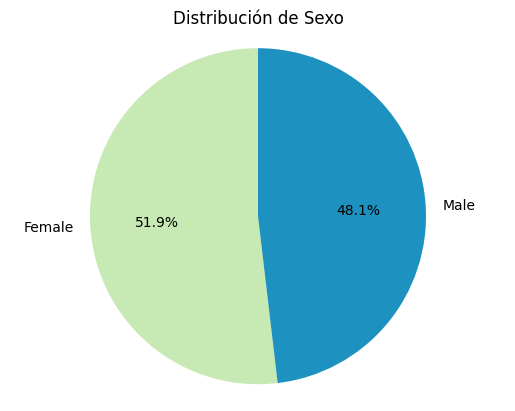

In [17]:
import matplotlib.pyplot as plt

# Contar el número de hombres y mujeres del dataset
count = health_data['Sex'].value_counts()

# Definir los colores
colors = ['#c7e9b4', '#1d91c0']

# Crear el gráfico de sectores
plt.pie(count, labels=count.index, autopct='%1.1f%%', startangle=90, colors=colors)

# Añadir título al gráfico
plt.title('Distribución de Sexo')

# Mostrar el gráfico
plt.axis('equal')
plt.show()

## **Casos por patología**

In [18]:
from tabulate import tabulate
import pandas as pd

disease_columns = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis']

disease_summary = {}

for col in disease_columns:
    counts = health_data[col].value_counts().to_dict()
    disease_summary[col] = {'Yes': counts.get('Yes', 0), 'No': counts.get('No', 0)}

df_disease_summary = pd.DataFrame(disease_summary).T
df_disease_summary.index.name = 'Patología'

print(tabulate(df_disease_summary, headers='keys', tablefmt='pretty', numalign='left'))

+---------------+--------+--------+
|   Patología   |  Yes   |   No   |
+---------------+--------+--------+
| Heart_Disease | 24971  | 283883 |
|  Skin_Cancer  | 29994  | 278860 |
| Other_Cancer  | 29878  | 278976 |
|  Depression   | 61901  | 246953 |
|   Diabetes    | 40171  | 259141 |
|   Arthritis   | 101071 | 207783 |
+---------------+--------+--------+


# **Patología por sexo**

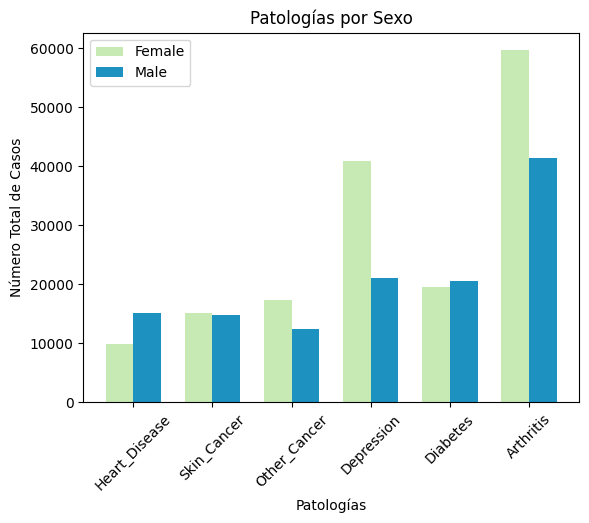

In [19]:
# Seleccionar las variables de interés
variables = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis']

# Contar el número de filas totales por 'Sex' y variable
counts = health_data.groupby('Sex')[variables].apply(lambda x: x.eq('Yes').sum())

# Crear el gráfico de barras
x = range(len(variables))  # Posiciones en el eje x
width = 0.35  # Ancho de las barras
fig, ax = plt.subplots()
rects1 = ax.bar(x, counts.loc['Female'], width, label='Female', color='#c7e9b4')
rects2 = ax.bar([i + width for i in x], counts.loc['Male'], width, label='Male', color='#1d91c0')

# Etiquetas, título y leyenda
ax.set_xlabel('Patologías')
ax.set_ylabel('Número Total de Casos')
ax.set_title('Patologías por Sexo')
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(variables, rotation=45)
ax.legend()

# Mostrar el gráfico
plt.show()


## Fumadores y el cancer por rango de **edad**

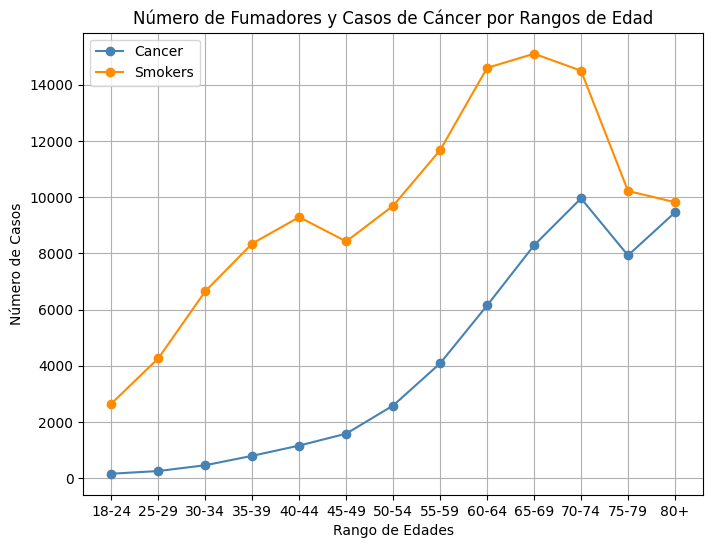

In [20]:
# Conteo de casos de cáncer 'Yes' para cada categoría de edad
cancer_counts = health_data[(health_data['Skin_Cancer'] == 'Yes') | (health_data['Other_Cancer'] == 'Yes')].groupby('Age_Category').size()

# Conteo de casos Smoking_History 'Yes' para cada categoría de edad
smoking_counts = health_data[health_data['Smoking_History'] == 'Yes'].groupby('Age_Category').size()

# Crear la gráfica de línea
plt.figure(figsize=(8, 6))
plt.plot(cancer_counts.index, cancer_counts.values, marker='o', color='steelblue', label='Cancer')
plt.plot(smoking_counts.index, smoking_counts.values, marker='o', color='darkorange', label='Smokers')
plt.xlabel('Rango de Edades')
plt.ylabel('Número de Casos')
plt.title('Número de Fumadores y Casos de Cáncer por Rangos de Edad')
plt.legend()
plt.grid(True)
plt.show()


## **Casos de depresión por peso y sexo**

/tmp/ipykernel_871/4049800502.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depression_counts = df[df['Depression'] == 'Yes'].groupby(['Weight_Status', 'Sex']).size().unstack()


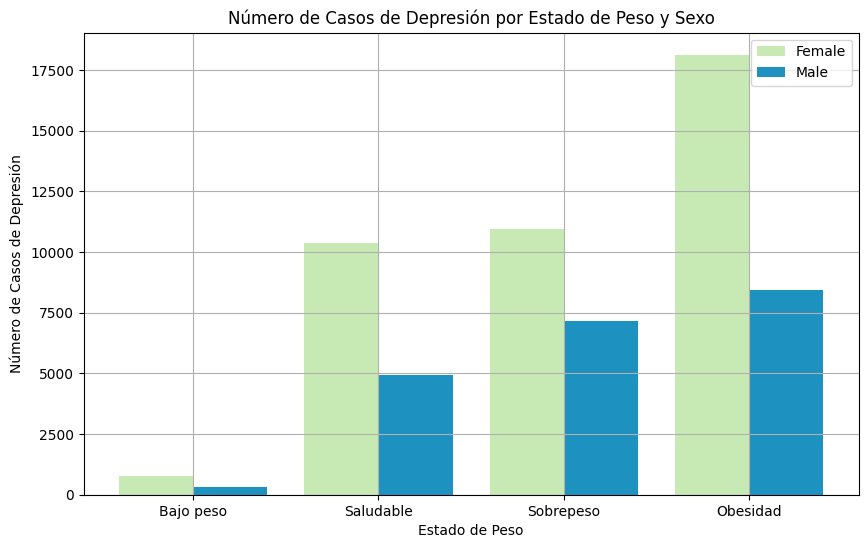

In [21]:
# Calcular el conteo de casos de depresión 'Yes' para cada combinación de 'Weight_Status' y 'Sex'
depression_counts = df[df['Depression'] == 'Yes'].groupby(['Weight_Status', 'Sex']).size().unstack()

# Definir el orden deseado para el eje x (usando los nombres correctos en español)
order = ['Bajo peso', 'Saludable', 'Sobrepeso', 'Obesidad']

# Reordenar los datos según el orden deseado
depression_counts = depression_counts.reindex(order)

# Crear el gráfico de barras agrupado
plt.figure(figsize=(10, 6))
width = 0.4
x = range(len(depression_counts.index))

plt.bar(x, depression_counts['Female'], width=width, label='Female', color='#c7e9b4')
plt.bar([i + width for i in x], depression_counts['Male'], width=width, label='Male', color='#1d91c0')

plt.xlabel('Estado de Peso')
plt.ylabel('Número de Casos de Depresión')
plt.title('Número de Casos de Depresión por Estado de Peso y Sexo')
plt.xticks([i + width/2 for i in x], depression_counts.index)
plt.legend()
plt.grid(True)
plt.show()

## Matriz de Correlación

### **Distribución de Enfermedades por Estado de Peso**

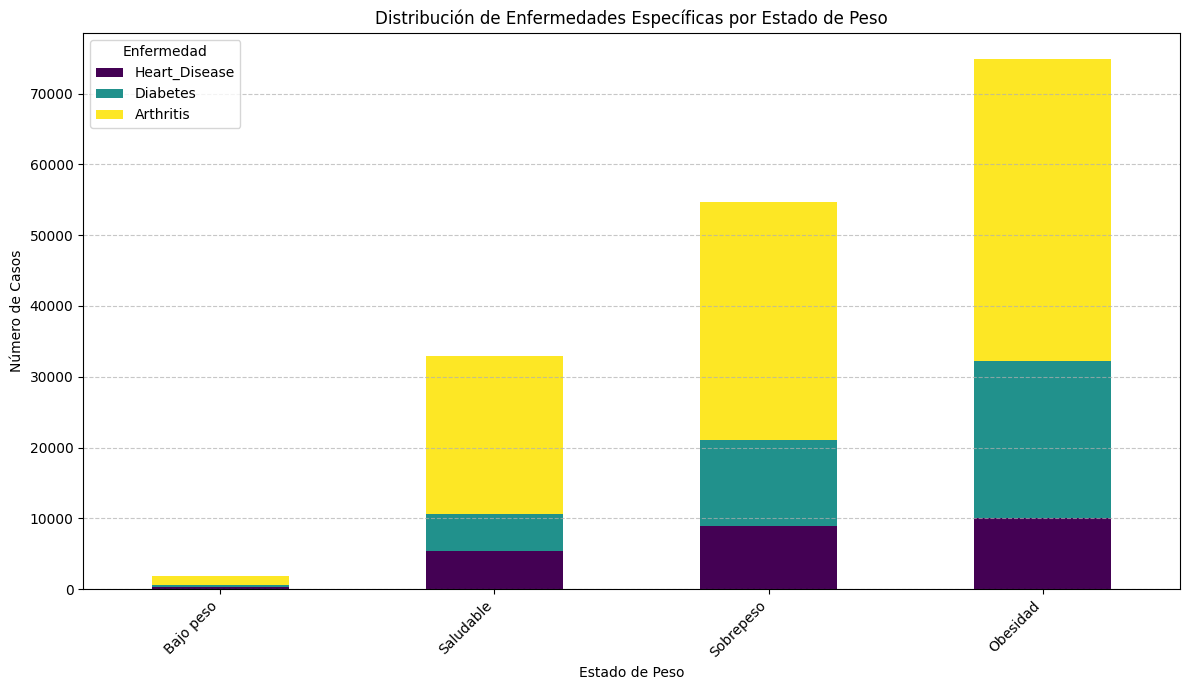

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the diseases of interest
diseases_of_interest = ['Heart_Disease', 'Diabetes', 'Arthritis']

# Create a DataFrame to store the counts of 'Yes' for each disease within each Weight_Status
disease_by_weight_status = pd.DataFrame()

for disease in diseases_of_interest:
    # Count 'Yes' occurrences for the current disease within each Weight_Status
    counts = health_data[health_data[disease] == 'Yes'].groupby('Weight_Status').size()
    disease_by_weight_status[disease] = counts

# Fill NaN values with 0 (in case a disease has no 'Yes' counts for a specific weight status)
disease_by_weight_status = disease_by_weight_status.fillna(0)

# Define the desired order for Weight_Status
weight_order = ['Bajo peso', 'Saludable', 'Sobrepeso', 'Obesidad']

# Reindex to ensure consistent order for plotting
disease_by_weight_status = disease_by_weight_status.reindex(weight_order)

# Plot the stacked bar chart
disease_by_weight_status.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Distribución de Enfermedades Específicas por Estado de Peso')
plt.xlabel('Estado de Peso')
plt.ylabel('Número de Casos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Enfermedad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Número Total de Enfermedades por Rango de Edad**

/tmp/ipykernel_871/219812787.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_diseases_by_age.index, y=total_diseases_by_age.values, palette='coolwarm')


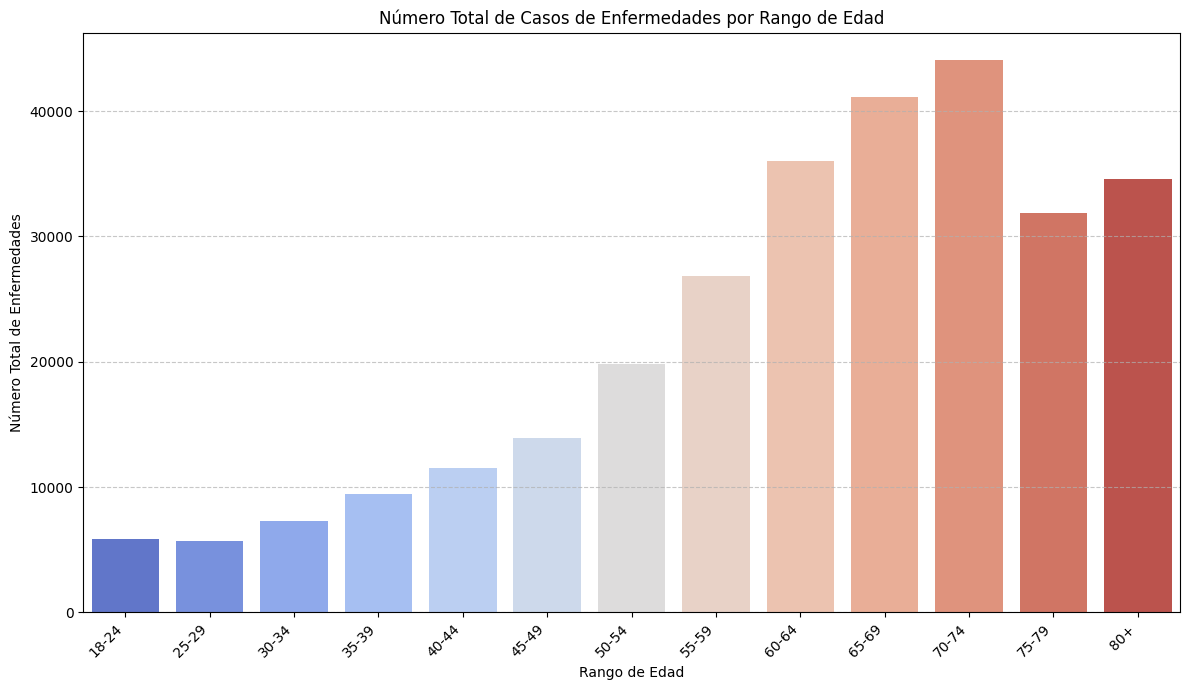

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by Age_Category and sum Total_Diseases
total_diseases_by_age = health_data.groupby('Age_Category')['Total_Diseases'].sum()

# Define the desired order for Age_Category
age_order = [
    '18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
    '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'
]

# Reindex to ensure consistent order for plotting
total_diseases_by_age = total_diseases_by_age.reindex(age_order)

# Plot the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=total_diseases_by_age.index, y=total_diseases_by_age.values, palette='coolwarm')
plt.title('Número Total de Casos de Enfermedades por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Número Total de Enfermedades')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Impacto del Ejercicio en el Número Promedio de Enfermedades**

/tmp/ipykernel_871/71226359.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_diseases_by_exercise.index, y=average_diseases_by_exercise.values, palette='coolwarm')


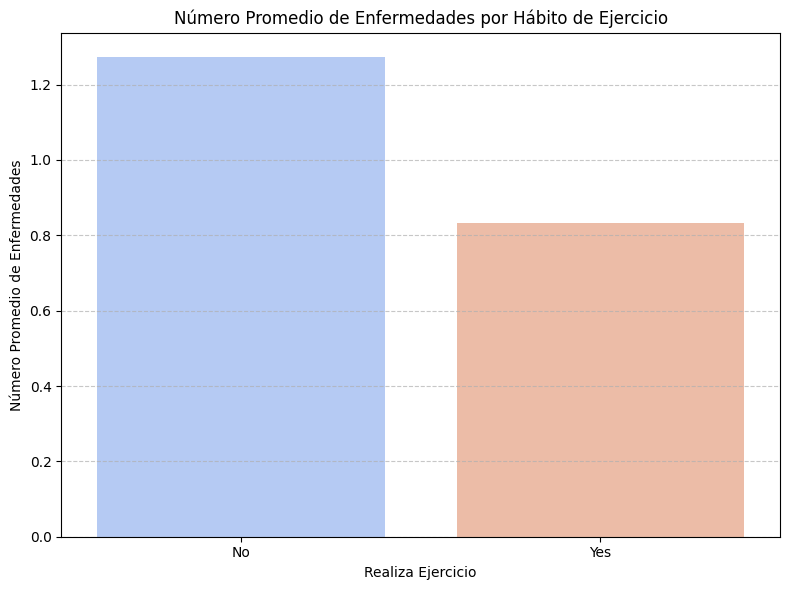

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average Total_Diseases for each Exercise category
average_diseases_by_exercise = health_data.groupby('Exercise')['Total_Diseases'].mean()

# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=average_diseases_by_exercise.index, y=average_diseases_by_exercise.values, palette='coolwarm')
plt.title('Número Promedio de Enfermedades por Hábito de Ejercicio')
plt.xlabel('Realiza Ejercicio')
plt.ylabel('Número Promedio de Enfermedades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

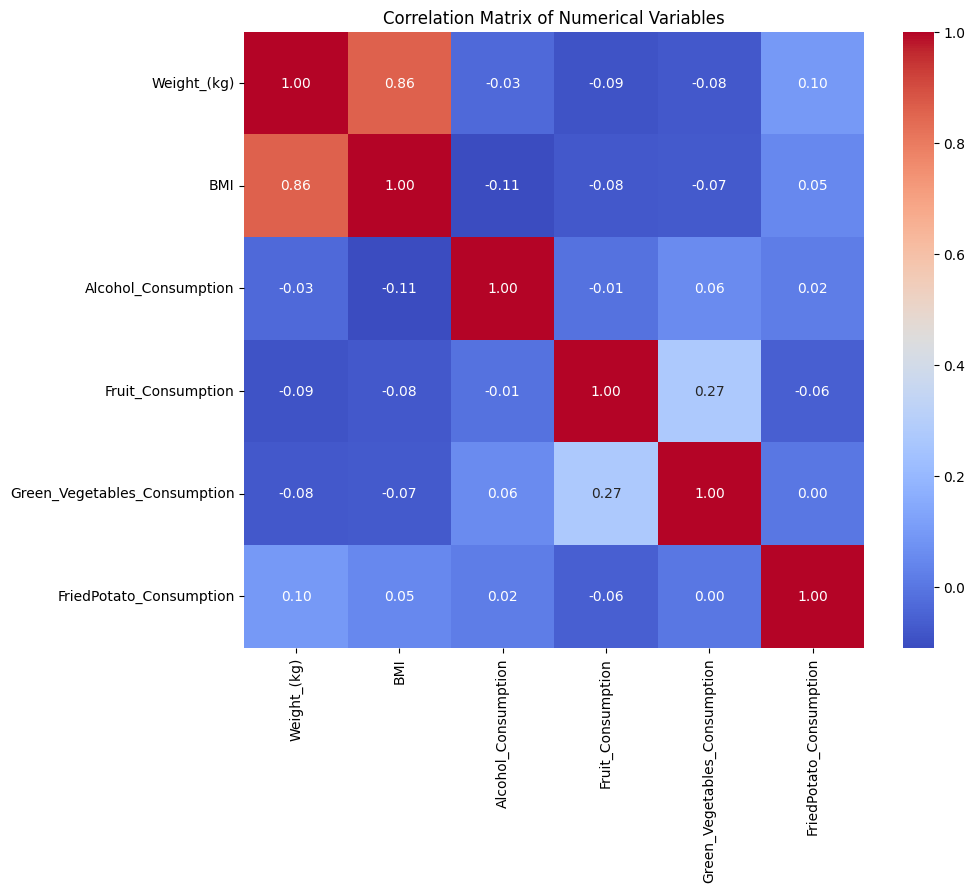

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = ['Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
df_numerical = df[numerical_cols]

# Calculate the correlation matrix
corr_matrix = df_numerical.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()